# PHSX 256 Topic 1: Python Basics

---
### Introduction

- See syllabus for course overview.

---
### How Do You Tell a Computer to Do Something?

- We are all used to graphical User Interfaces (GUIs).
- But how did someone make the GUI?
- For solving problems in science, we need more direct control.
- Often we will solve problems with highly repetitive *algorithms* - computers don't get bored!
- An algorithm is the conceptual steps that you want (a computer) to go through to solve a problem.
- If you write down an algorithm in steps in English that a human could follow, we often call that *pseudocode*.
- Writing down instructions for a computer in code it can understand is *programming* or *coding*, and the instructions are *computer code* or just *code*.
- There can be many implentations of an *algorithm* in *code*.
- There are many forms of *computer code*, often optimized for different purposes.

---
### Machine Code
- Direct instructions to CPU.
- All encoded as numbers.
- Example from the Python 3 interpreter with disassembled instructions:
```
425134:       0f 84 05 9c 0f 00       je     51ed3f <_PyToken_ThreeChars@@Base+0x5fcf>
42513a:       8b 83 90 00 00 00       mov    0x90(%rbx),%eax
425140:       8d 50 ff                lea    -0x1(%rax),%edx
425143:       31 c0                   xor    %eax,%eax
425145:       e9 39 9c 0f 00          jmp    51ed83 <_PyToken_ThreeChars@@Base+0x6013>
42514a:       8b b3 90 00 00 00       mov    0x90(%rbx),%esi
425150:       8d 56 ff                lea    -0x1(%rsi),%edx
425153:       e9 2b 9c 0f 00          jmp    51ed83 <_PyToken_ThreeChars@@Base+0x6013>
425158:       e8 44 d9 ff ff          call   422aa1 <getservbyname@plt+0xb21>
42515d:       83 7b 60 00             cmpl   $0x0,0x60(%rbx)
425161:       0f 84 68 9c 0f 00       je     51edcf <_PyToken_ThreeChars@@Base+0x605f>
425167:       8b 83 90 00 00 00       mov    0x90(%rbx),%eax
42516d:       8d 50 ff                lea    -0x1(%rax),%edx
425170:       31 c0                   xor    %eax,%eax
425172:       e9 9c 9c 0f 00          jmp    51ee13 <_PyToken_ThreeChars@@Base+0x60a3>
```

---
### Assembly Language
- More human-readable form of machine code.
- Turned into machine code by an *assembler*.
- One line of assembly is (usually) one instruction for CPU.
- Example from my graduate research:
```
   ;sin calculation
   MOVL XT, *XAR1
   QMPYXUL P, XT, @ALPHA_A    ;P=sindata(old)*alpha
   MOV T, @SIN_TEMP
   MPY ACC, T, @DATA_TEMP     ;ACC=sin*data
   SFR ACC, #ACC_SHIFT        ;shift result to give room to accumulate
   ADDL ACC, P                ;ACC=sin*data+sindata(old)*alpha
   MOVL *XAR1, ACC            ;store the new transform data
   MOVL XT, ACC
   QMPYL ACC, XT, *XAR1++     ;ACC=sindata^2
   MOVL @SIN_TEMP, ACC
   
   ;cos calculation
   MOVL XT, *XAR2
   QMPYXUL P, XT, @ALPHA_A    ;P=cosdata(old)*alpha
   MOV T, @COS_TEMP
   MPY ACC, T, @DATA_TEMP     ;ACC=cos*data
   SFR ACC, #ACC_SHIFT        ;shift result to give room to accumulate
   ADDL ACC, P                ;ACC=cos*data+cosdata(old)*alpha
   MOVL *XAR2, ACC            ;store the new transform data
   MOVL XT, ACC
   QMPYL ACC, XT, *XAR2++     ;ACC=cosdata^2
```

---
### Compiled Languages
- Compiled computer languages (e.g. Fortran, C, C++, Rust, ...) start with a platform-independent language.
- The language is usually much more human-readable than assembly.
- A *compiler* converts (compiles) the code into machine code / assembly.
- Compiled code runs fast!
- Modern compilers can sometimes generate faster code than hand-written assembly.
- Great for low-power systems, such as microcontrollers.
- Example from my Arduino code:
```
void loop() {
  // read the state of the pushbutton value:
  load_button_state = digitalRead(LOAD_BUTTON_PIN);
  // check if the load button is pressed; if it is, the button_state is LOW:
  if (load_button_state == LOW) {
    if(load_last_button_state == HIGH) {
      // trigger load sweep
      sweep(LOAD_FREQUENCY_MIN, LOAD_FREQUENCY_MAX, LOAD_FREQUENCY_STEP, LOAD_FREQUENCY_DWELL);
      // record last state
      load_last_button_state = LOW;
    }
  } else {
    if(load_last_button_state == LOW) {
      // button just released, delay a bit to debounce
      delay(100);
      load_last_button_state = HIGH;
    }
  }
}
```

---
### Interpreted Languages
- Intpreted languages (e.g. Python, Java, R, basic, ...) are not compiled to machine code.
- Instead, an *interpreter* program creates and passes instructions to the CPU and keeps track of the state.
- Interpreted code is (usually) easier to write but may run much (e.g. 50x) slower.
- Often a good trade-off when computer speed is cheaper than programmer time.
- Careful programming can make some interpreted code run as fast as compiled code (or occasionally faster).
- Example Python code:
```python
print("Hello, World!")
```

---
### Python

- Python is a high-level, interpreted, general-purpose programming language.
- First released in 1991 by Guido van Rossum.
- Named after Monty Python.
- Python3 (2008) made major changes to the language.
- By some measures, Python is the most popular programming language in the world.
- Used extensively in physics for modelling, experiment control, and data analysis.

---
### Installing Python

- For scientific computing on Windows/Mac, the easiest method is installing the Anaconda distribution.
- Anaconda bundles Python with essential libraries (NumPy, SciPy, Matplotlib) and tools (Jupyter, Spyder). 
- Download the installer from www.anaconda.com/download and follow the prompts, ensuring you check the box to add Anaconda to your PATH.
- On Linux, typically use your package manager (but you might want to consider virtual environments).

---
### Running Python

- Run locally through Anaconda in the Python *console* or *shell*.
- Available within some *integrated development environments* or *IDEs*, such as Spyder.
- Online Python3 interpreter: https://pyodide.org/en/stable/console.html

#### Local versus Online

- Online environments usually require no installation.
- Local environments are usually faster and make local file access easier, but require setup.
- I do my serious work in Spyder locally on my Linux desktop computer.

---
### Jupyter Notebooks

- Notebook interfaces let you mix code, graphic al output (e.g. plots), annotations and more in a single file.
- The most popular notebook interface for Python is known as Jupyter notebooks.
- Jupyter notebooks run in a web browser, connected to a local Python interpreter known as the *kernel*.
- I am using Jupyter notebooks for lectures in PHSX 256.
- Both local and online Jupyter notebook environments exist, with similar advantages and disadvantages to running Python locally or remotely.
- Online Jupyter notebook: https://jupyterlite.github.io/demo
- PHSX 256 online Jupyter notebook for controlled testing environment: https://dursobr.github.io/jupyterlite/

---
## Examples

- Working with the Python console.
- Tour of Jupyter.

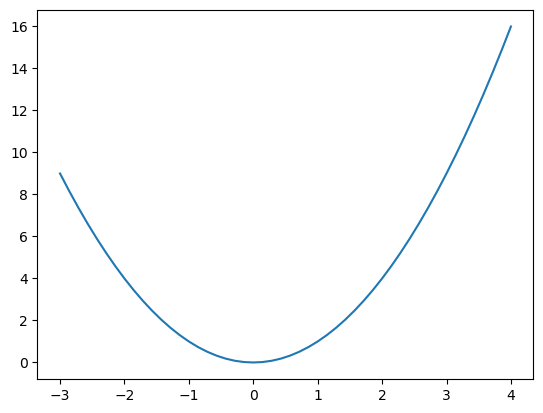

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 4, num=50)
plt.plot(x, x**2)

---
## Printed Output

- In Python, we use the `print()` function to display information as text.
- Strings (text) must be wrapped in quotes (`" "` or `' '`).
- For objects that are not text, print tries to convert them into text that reasonably represents them.
  - Advanced: internally, this uses an object's `__str__()` method.
- `print()` can handle multiple *arguments*, separated by commas. It will display them separated by a space.
- It is possible to change the separation character (default: one space), the ending character (default: a newline), and the destination (default: the screen, a.k.a. *stdout*). See detailed documentation at https://docs.python.org/3/library/functions.html#print

---
### Example

In [11]:
print("Hello")
print(7)
print("g =", 9.8, "m/s^2")

Hello
,7
,g = 9.8 m/s^2


---
## Comments

- In Python, comments start with a `#`.
- Everything on a line after a `#` does nothing, it just informs the reader/programmer.
- Use comments to explain what your code does, but don't just restate the obvious
- Comments can take up the whole line, like
```
# add two numbers; not a very informative comment 
6+7
```
- Or comments can be at the end of a line
```
6+7 # add two numbers
```
- Using lots of informative comments is highly encouraged!
- Note that different programming languages use different characters to indicate a comment.

---
### Example

In [13]:
# add two numbers
# the answer should be 13
print(6 + 7)

13


---
## Variables and Data Types

Think of a variable as a labeled box. You can store a value inside it and refer to it later by its name.

Rules for naming variables:

- Must start with a letter or an underscore (starting with an underscore is usually reserved for some special cases).
- Cannot contain spaces.
- Should be descriptive (e.g., user_age is better than a).

There are many types of values or objects in Python. A variable can hold an object of any type.

Some common types we will encounter include:

- Strings: a series of letters, numbers, or symbols indicated by surrounded them with `" "` or `' '`.
- Numeric types: integers, decimals, complex numbers, and more. We will go into these in more detail in the future.
- Lists, sequences, arrays, and more. We will spend a lot of time on these.
- Boolean: `True` or `False`.
- NoneType: Python has a special object to represent nothing: `None`.
- User-defined: it is possible to create new object types in Python! We won't do much of this.

---
### Example

In [12]:
# Assigning values to variables
username = "Alex"      # A String (text)
score = 95             # An Integer (whole number)
is_passing = True      # A Boolean (True/False)

# Using variables in output
print("Student Name:", username)
print("Final Score:", score)

Student Name: Alex
,Final Score: 95


---
## Importing Libraries

A lot of the functionality in Python is not built in to the basic language, but is added from *libraries*.

- Libraries are imported with an `import` statement, most commonly at the start of your code, e.g.
```
import math
```
- Functions from the imported library are then used with the help of a `.`, e.g.
```
import math
math.sqrt(2)
```
- Using `as`, the name of the library used in the code can be abbreviated or changed, e.g. 
```
import math as m
m.sqrt(2)
```
- Scientific code often starts with two import statements for array manipulation and plotting:
```
import numpy as np
import matplotlib.pyplot as plt
```
- There are many variations of the import statement to import only some items from a library, to avoid having to retype the library name many times, etc.


---
### Common Libraries

There are many libraries in the Python *standard library* (https://docs.python.org/3/library/index.html), which is normally part of every Python installation. We may use:

- string — Common string operations
- math — Mathematical functions
- cmath — Mathematical functions for complex numbers
- csv — CSV file reading and writing
- os — Miscellaneous operating system interfaces
- os.path — Common pathname manipulations


There are even more outside the standard library, most importantly:

- numpy — Arrays and array operations (most commonly imported as `import numpy as np`), see https://numpy.org/
- matplotlib — Plotting (most commonly imported as `import matplotlib.pyplot as plt`), see https://matplotlib.org/
- scipy — Collection of numerical algorithms for scientific applications, see https://scipy.org/

---
## Files and File Systems

Before we write to files, we need to understand where they live. Python uses the os (Operating System) library to look at folders and paths.

- *Filesystems* consist of information (data, executables, etc.) stored in *files*.
- Files are organized in nested *folders* or *directories*.
- The details of filesystems are typically hidden on phones and tablets, but visible on desktop computers.
- Files may be stored *locally* (on your computer) or *remotely* if they are only accessed through a network.
- Files often (but not always) have a *type*, and it may be indicated by a period and a three-letter extension, e.g. `.txt`, `.doc`, or `.exe`.

---
### Example

In [16]:
import os

# Check your current location (Working Directory)
current_folder = os.getcwd()
print("We are currently working in:", current_folder)

# List all files in the current folder
print("Files in this folder:", os.listdir())

We are currently working in: /home/durso/Dropbox/MSU/classes/2025-2026_PHSX_256/lectures
,Files in this folder: ['lecture_01.ipynb', 'lecture_02.ipynb', 'Untitled.ipynb', '.ipynb_checkpoints', 'note.txt', 'lecture_0.ipynb']


## Reading and Writing Files

In Python, handling a file involves three steps: Open → Process → Close.

`open(filename, mode='r')`

- 'w' mode: Write (creates a new file or overwrites an existing one).

- 'r' mode: Read (opens a file to see what is inside).

- 'a' mode: Append (adds text to the end of a file).

Tip: Using the with keyword is the safest way to handle files because it closes the file automatically for you!

In [15]:
# 1. Writing to a file

file = open("note.txt", "w")
file.write("This is my first Python-generated file!\n")
file.write("Variables and files are powerful tools.")
file.close()

# or

with open("note.txt", "w") as file:
    file.write("This is my first Python-generated file!\n")
    file.write("Variables and files are powerful tools.")

print("File 'note.txt' has been created.")

# 2. Reading from the file

file = open("note.txt", "r")
content = file.read()
print("\n--- Content of the file ---")
print(content)

# or

with open("note.txt", "r") as file:
    content = file.read()
    print("\n--- Content of the file ---")
    print(content)

File 'note.txt' has been created.
,
,--- Content of the file ---
,This is my first Python-generated file!
,Variables and files are powerful tools.
,
,--- Content of the file ---
,This is my first Python-generated file!
,Variables and files are powerful tools.


## Summary

| Feature | Python | Purpose |
|:--------|:-------|:--------|
| Output  | `print()` | Shows data on the screen. |
| Comments | `#`      | Explains code; ignored by Python. |
| Variables | `name = value` | Stores data for later use. |
| File Opening | `open("filename", "mode")` | Connects Python to a physical file. |
| Directory | `os.getcwd()` | Finds where your code is running. |